In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [2]:
import random
import numpy as np
import os
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)

In [3]:
!pip install -q pytorchvideo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 31.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    RandomPerspective,
    Pad,
    Resize,
)

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


In [5]:
import os
import torchvision
resize_to = 224
class Padding(torch.nn.Module):
  def __init__(self, min_height, min_width):
    super().__init__()
    self.min_height = min_height
    self.min_width = min_width

  def forward(self, images):
    if images.shape[1] < self.min_height:
        images = torchvision.transforms.functional.pad(images, (0,0,0,(self.min_height-images.shape[1])))
    if images.shape[2] < self.min_width:
        images = torchvision.transforms.functional.pad(images, (0,0,self.min_width - images.shape[2], 0))
    return images

train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(16),
                    Lambda(lambda x: x / 255.0),
                    Normalize((0.45, 0.45, 0.45), (0.225, 0.225, 0.225)),
                    #RandomShortSideScale(min_size=100, max_size=128),
                    RandomHorizontalFlip(p=0.5),
                    RandomPerspective(distortion_scale=0.35, p=0.7),
                    Padding(min_height=200, min_width=200),
                    Resize((resize_to, resize_to))
                ]
            ),
        ),
    ]
)


In [6]:
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights

model = mvit_v2_s(weights=MViT_V2_S_Weights.KINETICS400_V1)
transforms = MViT_V2_S_Weights.KINETICS400_V1.transforms()


Downloading: "https://download.pytorch.org/models/mvit_v2_s-ae3be167.pth" to /root/.cache/torch/hub/checkpoints/mvit_v2_s-ae3be167.pth
100%|██████████| 132M/132M [00:02<00:00, 51.5MB/s]


In [7]:
def freeze_weights(model):
  for param in model.parameters():
    param.requires_grad = False
  for j in range(12, 16):
    for param in model.blocks[j].parameters():
      param.requires_grad = True
  model.head[1] = torch.nn.Linear(768, 2)
  return model

model = freeze_weights(model)

In [21]:
#checkpoint = torch.load('/content/drive/MyDrive/checkpoint_3', map_location=device)
#model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import torch
import os
import os.path
from typing import Any, Callable, cast, Dict, List, Optional, Tuple, Union

from PIL import Image
def find_classes(directory: str):
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")

  class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx

def make_dataset(
    directory,
    class_to_idx = None,
):
    """Generates a list of samples of a form (path_to_sample, class).

    See :class:`DatasetFolder` for details.

    Note: The class_to_idx parameter is here optional and will use the logic of the ``find_classes`` function
    by default.
    """
    directory = os.path.expanduser(directory)

    if class_to_idx is None:
        _, class_to_idx = find_classes(directory)
    elif not class_to_idx:
        raise ValueError("'class_to_index' must have at least one entry to collect any samples.")

    instances = []
    available_classes = set()
    for target_class in sorted(class_to_idx.keys()):
        class_index = class_to_idx[target_class]
        target_dir = os.path.join(directory, target_class)
        if not os.path.isdir(target_dir):
            continue
        for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
            for fname in sorted(fnames):
                path = os.path.join(root, fname)
                item = path, class_index
                instances.append(item)
                if target_class not in available_classes:
                    available_classes.add(target_class)

    empty_classes = set(class_to_idx.keys()) - available_classes
    return instances


In [11]:
import cv2
from pytorchvideo.data.encoded_video import EncodedVideo
class HackDataset(torch.utils.data.Dataset):
     def __init__(self, root: str, transform: Optional[Callable] = None, clip_duration: float = 15.0):
        self.root = root
        classes, class_to_idx = find_classes(self.root)
        samples = make_dataset(self.root, class_to_idx)
        self.classes = classes
        self.class_to_idx = class_to_idx
        self.samples = samples
        self.transform = transform
        self.targets = [s[1] for s in samples]
        self.clip_duration = clip_duration



     def __len__(self):
        return len(self.samples)

     def __getitem__(self, index: int) -> Tuple[Any, Any]:
        """
        Args:
            index (int): Index

        Returns:
            tuple: (sample, target) where target is class_index of the target class.
        """

        path, target = self.samples[index]
        video = EncodedVideo.from_path(path)
        sample = video.get_clip(0.0, 0.0 + self.clip_duration)
        if self.transform is not None:
            sample = self.transform(sample)
            #sample = UniformTemporalSubsample(16)(sample)
        return sample['video'], target

In [12]:
import torchvision
import numpy as np
from sklearn.model_selection import train_test_split
dataset_full = HackDataset(root='/content/drive/MyDrive/for_classification', transform=train_transform)
batch_size = 8
# split full dataset
train_idx, valid_idx = train_test_split(list(range(len(dataset_full))), train_size=0.95)
dataset = {
    'train': torch.utils.data.Subset(dataset_full, train_idx),
    'valid': torch.utils.data.Subset(dataset_full, valid_idx)
}

dataset_size = {ds: len(dataset[ds]) for ds in ['train', 'valid']}


dataloader = {
    'train': torch.utils.data.DataLoader(
        dataset=dataset['train'], batch_size=batch_size, shuffle=True
    ),
    'valid': torch.utils.data.DataLoader(
        dataset=dataset['valid'], batch_size=batch_size, shuffle=False
    ),
}

In [13]:
dataset_full[0][0].shape

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


torch.Size([3, 16, 224, 224])

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


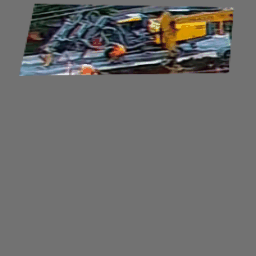

In [36]:
import imageio
import numpy as np
from IPython.display import Image

import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * np.array((0.225, 0.225, 0.225))) + np.array((0.45, 0.45, 0.45))
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.

    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

sample_video = dataset_full[1][0]
video_tensor = sample_video
display_gif(video_tensor)

In [50]:

torch.nn.functional.softmax(model(dataset_full[0][0].unsqueeze(0)), dim=-1)

tensor([[0.4506, 0.5494]], grad_fn=<SoftmaxBackward0>)

In [ ]:
!pip install torchensemble

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [14]:

def train_epoch(
    model: torch.nn.Module,
    optimizer: torch.optim,
    criterion: torch.nn.modules.loss._Loss,
    loader: torch.utils.data.DataLoader,
    device: torch.device
):
    acc_loss = 0
    total = len(loader.dataset)
    model.to(device)
    model.train()
    for data, target in tqdm.tqdm(loader):
        data = data.to(device)
        target = target.to(device)
        pred = torch.nn.functional.softmax(model(data), dim=-1)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        acc_loss += loss.item()

    return acc_loss / total

In [15]:
from collections import namedtuple
from typing import NamedTuple, List
from numba import jit
EvalOut = namedtuple("EvalOut", ['loss', 'accuracy'])


def eval_epoch(
    model: torch.nn.Module,
    criterion: torch.nn.modules.loss._Loss,
    loader: torch.utils.data.DataLoader,
    device: torch.device
):
    acc_loss = 0
    accuracy = 0
    total = len(loader.dataset)
    model.eval()
    model.to(device)
    with torch.inference_mode():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            pred = torch.nn.functional.softmax(model(data), dim=-1)
            loss = criterion(pred, target)
            acc_loss += loss.item()
            accuracy += torch.sum(torch.argmax(pred, 1) == target).item()

    return EvalOut(loss = (acc_loss / total), accuracy = (accuracy / total))


class TrainOut(NamedTuple):
    train_loss: List[float]
    eval_loss: List[float]
    eval_accuracy: List[float]


def train(
    model: torch.nn.Module,
    optimizer: torch.optim,
    criterion: torch.nn.modules.loss._Loss,
    sheduler: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    is_freeze_layers: bool,
    epochs: int = 10
):
    train_loss = []
    eval_loss = []
    eval_accuracy = []
    for i in range(epochs):
        print(f"Epoch - {i}\n")
        if (train_loader != None):
            print("Train...\n")
            train_loss.append(train_epoch(model, optimizer, criterion, train_loader, device))
        print("Validation...\n")
        eval_out = eval_epoch(model, criterion, val_loader, device)
        eval_loss.append(eval_out.loss)
        eval_accuracy.append(eval_out.accuracy)
        print(f'Validation acc: {eval_out.accuracy}')
        sheduler.step()
        if i > 1 and eval_accuracy[i] == max(eval_accuracy):
          torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            }, f'/content/drive/MyDrive/checkpoint_{i}')

    return TrainOut(train_loss = train_loss,
                    eval_loss = eval_loss,
                    eval_accuracy = eval_accuracy)


In [16]:
import matplotlib.pyplot as plt
def show_losses(TrainOut, epochs):
    plt.plot(epochs, TrainOut.train_loss, label=r'$train$')
    plt.plot(epochs, TrainOut.eval_loss, label=r'$val$')
    plt.xlabel(r'$epochs$', fontsize=14)
    plt.ylabel(r'$loss$', fontsize=14)
    plt.grid(True)
    plt.legend(loc='best', fontsize=12)
    plt.show()


def show_accuracy(accuracy, epochs):
    plt.plot(epochs, accuracy)
    plt.show()

def predict(model, dataloader_test):
    logits = []
    model.eval()
    with torch.no_grad():
        for inputs, _ in dataloader_test:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu()
            logits.append(outputs)
    probs = torch.nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [17]:
import tqdm
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
epochs = 15



In [57]:
tr_tuple = train(model, optimizer, criterion, sheduler, dataloader['train'], dataloader['valid'], device, False, epochs)
max(tr_tuple.eval_accuracy)

Epoch - 0

Train...



  0%|          | 0/182 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
100%|██████████| 182/182 [24:13<00:00,  7.99s/it]


Validation...

Validation acc: 0.7839506172839507
Epoch - 1

Train...



100%|██████████| 182/182 [05:18<00:00,  1.75s/it]


Validation...

Validation acc: 0.8703703703703703
Epoch - 2

Train...



...

100%|██████████| 182/182 [05:20<00:00,  1.76s/it]


Validation...

Validation acc: 0.8888888888888888
Epoch - 14

Train...



100%|██████████| 182/182 [05:24<00:00,  1.78s/it]


Validation...

Validation acc: 0.9135802469135802


0.9135802469135802

In [67]:
tr_tuple = train(model, optimizer, criterion, sheduler, dataloader['train'], dataloader['valid'], device, False, 10)
max(tr_tuple.eval_accuracy)

Epoch - 0

Train...



100%|██████████| 182/182 [05:29<00:00,  1.81s/it]


Validation...

Validation acc: 0.9012345679012346
Epoch - 1

Train...



100%|██████████| 182/182 [05:33<00:00,  1.83s/it]


Validation...

Validation acc: 0.9135802469135802
Epoch - 2

Train...



...

100%|██████████| 182/182 [05:26<00:00,  1.79s/it]


Validation...

Validation acc: 0.9259259259259259
Epoch - 9

Train...



100%|██████████| 182/182 [05:30<00:00,  1.82s/it]


Validation...

Validation acc: 0.9197530864197531


0.9382716049382716

In [ ]:
tr_tuple = train(model, optimizer, criterion, sheduler, dataloader['train'], dataloader['valid'], device, False, 10)
max(tr_tuple.eval_accuracy)

Epoch - 0

Train...



100%|██████████| 182/182 [05:28<00:00,  1.80s/it]


Validation...

Validation acc: 0.9197530864197531
Epoch - 1

Train...



100%|██████████| 182/182 [05:27<00:00,  1.80s/it]


Validation...

Validation acc: 0.9197530864197531
Epoch - 2

Train...



...

100%|██████████| 182/182 [05:25<00:00,  1.79s/it]


Validation...

Validation acc: 0.9382716049382716
Epoch - 4

Train...



100%|██████████| 182/182 [05:26<00:00,  1.79s/it]


Validation...

Validation acc: 0.9197530864197531
Epoch - 5

Train...



 96%|█████████▌| 174/182 [05:14<00:20,  2.62s/it]

In [72]:
test_dataset = HackDataset(root='/content/drive/MyDrive/test_class', transform=train_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8)

In [68]:
test_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(16),
                    Lambda(lambda x: x / 255.0),
                    Normalize((0.45, 0.45, 0.45), (0.225, 0.225, 0.225)),
                    #RandomShortSideScale(min_size=100, max_size=128),
                    #RandomHorizontalFlip(p=0.5),
                    #RandomPerspective(distortion_scale=0.35, p=0.7),
                    Padding(min_height=200, min_width=200),
                    Resize((resize_to, resize_to))
                ]
            ),
        ),
    ]
)

##Эксперименты с onnx

In [ ]:
torch.onnx.export(model, dataset_full[0][0].unsqueeze(0).to(device), '/content/drive/MyDrive/onnx_model')

In [17]:
checkpoint = torch.load('/content/drive/MyDrive/checkpoint_3', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [66]:
torch.nn.functional.softmax(model(dataset_full[0][0].unsqueeze(0).to(device)), dim=-1)

tensor([[9.9988e-01, 1.1786e-04]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [ ]:
test_tuple = train(model, optimizer, criterion, sheduler, None, dataloader['valid'], device, False, 1)
max(test_tuple.eval_accuracy)

Epoch - 0

Validation...



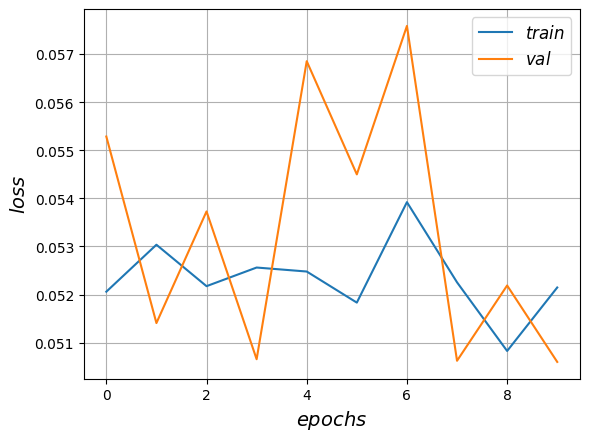

In [75]:
show_losses(tr_tuple, list(range(10)))

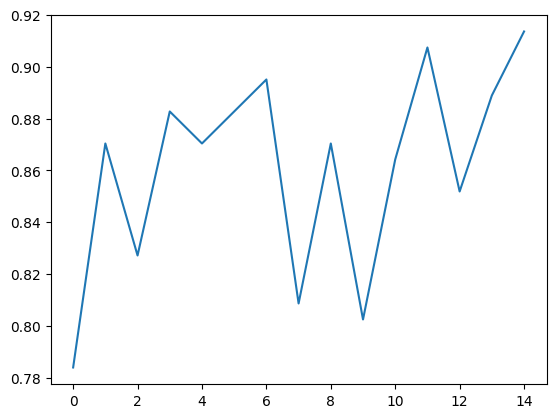

In [59]:
show_accuracy(tr_tuple.eval_accuracy, list(range(epochs)))

##Inference code:

In [79]:
def convert_from_torch_to_onnx(
        onnx_path: str,
        model,
        dataset
) -> None:
    """Конвертация модели из формата PyTorch в формат ONNX.

    @param onnx_path: путь к модели в формате ONNX
    @param tokenizer: токенизатор
    @param model: модель
    """
    dummy_model_input = dataset[0][0].unsqueeze(0).to(device)
    torch.onnx.export(
        model,
        dummy_model_input,
        onnx_path,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'},
                      'output': {0: 'batch_size'}}
    )

In [81]:
!pip install onnx

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 95.1 MB/s eta 0:00:00


In [82]:
convert_from_torch_to_onnx('/content/drive/MyDrive/model.onnx', model, dataset_full)

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================



In [84]:
!pip install onnxruntime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 104.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.5 MB/s eta 0:00:00


In [85]:
from onnxruntime.quantization import (
    quantize_dynamic,
    QuantType
)


def convert_from_onnx_to_quantized_onnx(
        onnx_model_path: str,
        quantized_onnx_model_path: str
) -> None:
    """Квантизация модели в формате ONNX до Int8
    и сохранение кванитизированной модели на диск.

    @param onnx_model_path: путь к модели в формате ONNX
    @param quantized_onnx_model_path: путь к квантизированной модели
    """
    quantize_dynamic(
        onnx_model_path,
        quantized_onnx_model_path,
        weight_type=QuantType.QUInt8
    )

In [86]:
import onnxruntime
from onnxruntime import (
    InferenceSession,
    SessionOptions
)


def create_onnx_session(
        model_path: str,
) -> InferenceSession:
    """Создание сессии для инференса модели с помощью ONNX Runtime.

    @param model_path: путь к модели в формате ONNX
    @param provider: инференс на ЦП
    @return: ONNX Runtime-сессия
    """
    options = SessionOptions()
    options.graph_optimization_level = \
        onnxruntime.GraphOptimizationLevel.ORT_ENABLE_ALL
    options.intra_op_num_threads = 1
    session = InferenceSession(model_path, options, providers=["GPUExecutionProvider", "CPUExecutionProvider"])
    session.disable_fallback()
    return session


In [ ]:
pred = model(dataset_full[1][0].unsqueeze(0))

In [ ]:
dataset_full[1][0].unsqueeze(0).shape

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


torch.Size([1, 64, 3, 224, 224])